In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("✅ Library siap digunakan!")

✅ Library siap digunakan!


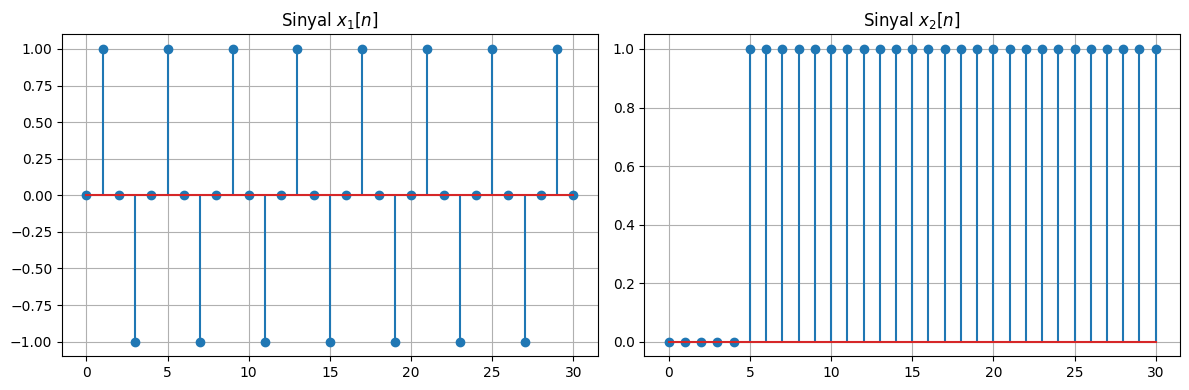

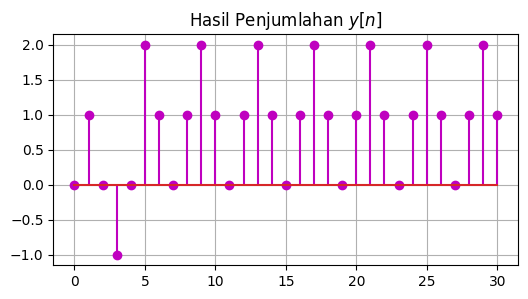

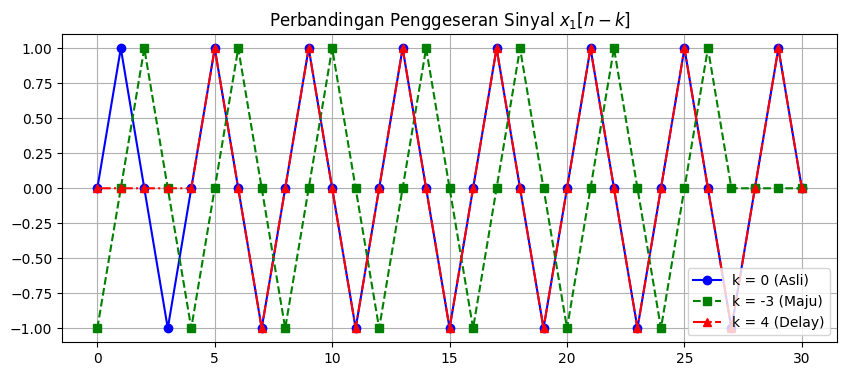

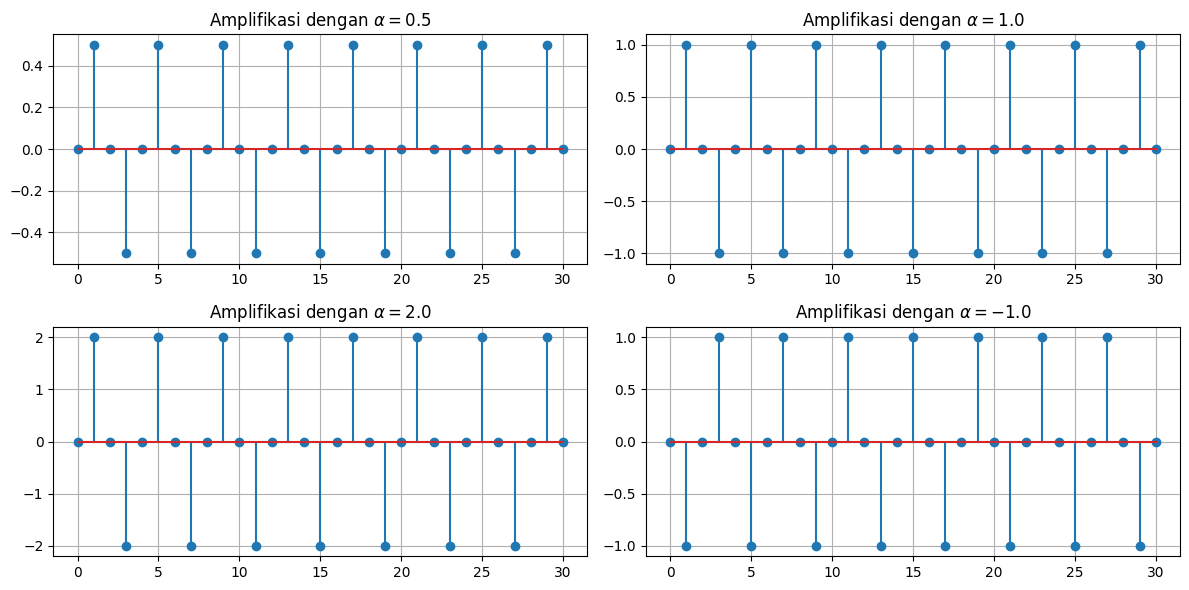

In [18]:
# A.1 Membuat Sinyal Diskrit
n = np.arange(0, 31) # n = 0 sampai 30
x1 = np.sin(0.5 * np.pi * n) # x1[n] = sin(0.5*pi*n)
x2 = np.where(n >= 5, 1.0, 0.0) # Sinyal unit step n >= 5

# Visualisasi Sinyal Asli
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.stem(n, x1); plt.title('Sinyal $x_1[n]$'); plt.grid(True)
plt.subplot(1, 2, 2); plt.stem(n, x2); plt.title('Sinyal $x_2[n]$'); plt.grid(True)
plt.tight_layout(); plt.show()

# A.2 Operasi Penjumlahan Sinyal
y_add = x1 + x2 # y[n] = x1[n] + x2[n]

plt.figure(figsize=(6, 3))
plt.stem(n, y_add, linefmt='m-', markerfmt='mo')
plt.title('Hasil Penjumlahan $y[n]$')
plt.grid(True); plt.show()

# A.3 Operasi Penggeseran Sinyal
def geser_sinyal(sinyal, k):
    shifted = np.zeros_like(sinyal)
    for i in range(len(sinyal)):
        if 0 <= i - k < len(sinyal):
            shifted[i] = sinyal[i - k]
    return shifted

x_k_neg3 = geser_sinyal(x1, -3) # k = -3
x_k_0 = geser_sinyal(x1, 0)     # k = 0
x_k_4 = geser_sinyal(x1, 4)     # k = 4

plt.figure(figsize=(10, 4))
plt.plot(n, x_k_0, 'b-o', label='k = 0 (Asli)')
plt.plot(n, x_k_neg3, 'g--s', label='k = -3 (Maju)')
plt.plot(n, x_k_4, 'r-.^', label='k = 4 (Delay)')
plt.title('Perbandingan Penggeseran Sinyal $x_1[n-k]$')
plt.legend(); plt.grid(True); plt.show()

# A.4 Operasi Amplifikasi Sinyal
alphas = [0.5, 1.0, 2.0, -1.0] # Nilai alpha
plt.figure(figsize=(12, 6))
for i, a in enumerate(alphas, 1):
    plt.subplot(2, 2, i)
    plt.stem(n, a * x1) # y[n] = alpha * x[n]
    plt.title(f'Amplifikasi dengan $\\alpha = {a}$')
    plt.grid(True)
plt.tight_layout(); plt.show()

In [19]:
# B.1 Membaca Citra
nama_gambar = 'citra.jpg' # SESUAIKAN NAMA FILE KAMU!
img1 = cv2.imread(nama_gambar, cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print(f"❌ File '{nama_gambar}' belum ter-upload atau namanya salah!")
else:
    print(f"✅ Citra 1 Berhasil Dimuat! Ukuran: {img1.shape}, Tipe: {img1.dtype}")
    print(f"Nilai Pixel Min: {img1.min()}, Max: {img1.max()}")

    # Membuat Citra 2 buatan dengan ukuran sama untuk penjumlahan
    img2 = np.zeros_like(img1)
    cv2.putText(img2, 'PSD 2026', (img1.shape[1]//4, img1.shape[0]//2),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

    # B.2 Operasi Penjumlahan Citra (Metode Clipping)
    img_hasil_penjumlahan = cv2.add(img1, img2) # I(i,j) = I1(i,j) + I2(i,j)

    # Tampilkan Penjumlahan
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title('Citra Asli 1'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(img2, cmap='gray'); plt.title('Citra 2'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(img_hasil_penjumlahan, cmap='gray'); plt.title('Hasil Penjumlahan'); plt.axis('off')
    plt.show()

    # B.3 Operasi Penggeseran Citra (Translasi)
    rows, cols = img1.shape
    M = np.float32([[1, 0, 30], [0, 1, 30]]) # Pergeseran delta i=30, delta j=30
    img_shifted = cv2.warpAffine(img1, M, (cols, rows))

    plt.figure(figsize=(6, 3))
    plt.imshow(img_shifted, cmap='gray')
    plt.title('Citra Hasil Penggeseran (X=30, Y=30)')
    plt.axis('off'); plt.show()

    # B.4 Operasi Amplifikasi Citra
    alphas_citra = [0.5, 1.0, 1.5, 2.0]
    plt.figure(figsize=(14, 7))
    idx = 1
    for a in alphas_citra:
        # Jalankan perkalian skalar dan batasi 0-255 (Clipping)
        img_amp = np.clip(a * img1.astype(float), 0, 255).astype(np.uint8)

        # Plot Citra Hasil Amplifikasi
        plt.subplot(2, 4, idx)
        plt.imshow(img_amp, cmap='gray', vmin=0, vmax=255)
        plt.title(f'Citra $\\alpha = {a}$')
        plt.axis('off')

        # Plot Histogram
        plt.subplot(2, 4, idx + 4)
        plt.hist(img_amp.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.6)
        plt.title(f'Histogram $\\alpha = {a}$')

        idx += 1
    plt.tight_layout(); plt.show()

❌ File 'citra.jpg' belum ter-upload atau namanya salah!


In [22]:
# Definisikan dua sistem sesuai perintah panduan [cite: 186]
def T1(x): return 2 * x   # Sistem 1 [cite: 187]
def T2(x): return x ** 2  # Sistem 2 [cite: 188]

# Sinyal input uji sederhana [cite: 162]
x_uji1 = np.array([1.0, 2.0, 3.0])
x_uji2 = np.array([0.5, 1.0, 1.5])
alpha_uji = 3.0 # Parameter alpha untuk homogenitas [cite: 166]

print("=== 1. UJI SISTEM T1(x) = 2x ===")
# Sifat Homogenitas: T(a*x) harus sama dengan a*T(x) [cite: 165]
homogen_kiri_T1 = T1(alpha_uji * x_uji1)
homogen_kanan_T1 = alpha_uji * T1(x_uji1)
print(f"T(a*x) : {homogen_kiri_T1} | a*T(x) : {homogen_kanan_T1}")
print(f"-> Memenuhi Homogenitas? {np.array_equal(homogen_kiri_T1, homogen_kanan_T1)}")

# Sifat Additivitas: T(x1 + x2) harus sama dengan T(x1) + T(x2) [cite: 177]
additif_kiri_T1 = T1(x_uji1 + x_uji2)
additif_kanan_T1 = T1(x_uji1) + T1(x_uji2)
print(f"T(x1+x2): {additif_kiri_T1} | T(x1)+T(x2): {additif_kanan_T1}")
print(f"-> Memenuhi Additivitas? {np.array_equal(additif_kiri_T1, additif_kanan_T1)}\n")


print("=== 2. UJI SISTEM T2(x) = x^2 ===")
# Sifat Homogenitas [cite: 165]
homogen_kiri_T2 = T2(alpha_uji * x_uji1)
homogen_kanan_T2 = alpha_uji * T2(x_uji1)
print(f"T(a*x) : {homogen_kiri_T2} | a*T(x) : {homogen_kanan_T2}")
print(f"-> Memenuhi Homogenitas? {np.array_equal(homogen_kiri_T2, homogen_kanan_T2)}")

# Sifat Additivitas [cite: 177]
additif_kiri_T2 = T2(x_uji1 + x_uji2)
additif_kanan_T2 = T2(x_uji1) + T2(x_uji2)
print(f"T(x1+x2): {additif_kiri_T2} | T(x1)+T(x2): {additif_kanan_T2}")
print(f"-> Memenuhi Additivitas? {np.array_equal(additif_kiri_T2, additif_kanan_T2)}")

=== 1. UJI SISTEM T1(x) = 2x ===
T(a*x) : [ 6. 12. 18.] | a*T(x) : [ 6. 12. 18.]
-> Memenuhi Homogenitas? True
T(x1+x2): [3. 6. 9.] | T(x1)+T(x2): [3. 6. 9.]
-> Memenuhi Additivitas? True

=== 2. UJI SISTEM T2(x) = x^2 ===
T(a*x) : [ 9. 36. 81.] | a*T(x) : [ 3. 12. 27.]
-> Memenuhi Homogenitas? False
T(x1+x2): [ 2.25  9.   20.25] | T(x1)+T(x2): [ 1.25  5.   11.25]
-> Memenuhi Additivitas? False
